In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from  sklearn.metrics import silhouette_score

In [5]:
df = pd .read_csv('AI_Customer_Value_Churn_Segmentation_5000.csv')
df

,Customer_ID,Age,Gender,Tenure_Months,Recency_Days,Frequency,Monetary_Value,Total_Purchases,Avg_Purchase_Value,Support_Calls,Website_Visits,Discount_Usage_Percent,Satisfaction_Score,Churn,Customer_Value
0,CUST01502,30,Female,23,104,8,387.81,15,25.85,6,22,39,4.3,0,Low
1,CUST02587,21,Female,25,120,5,139.28,10,13.93,5,20,48,5.5,1,Low
2,CUST02654,47,Female,15,47,15,228.35,19,12.02,5,8,13,5.2,0,Low
3,CUST01056,29,Male,45,81,8,643.28,29,22.18,6,21,40,4.9,0,Low
4,CUST00706,43,Male,40,73,5,258.46,15,17.23,3,7,30,7.2,0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST04427,40,Female,24,104,26,1212.78,47,25.80,2,26,17,9.2,0,Medium
4996,CUST00467,43,Male,51,34,7,162.88,30,5.43,4,37,48,6.3,0,Low
4997,CUST03093,35,Male,44,31,15,628.31,64,9.82,0,108,27,8.2,0,Medium
4998,CUST03773,27,Male,76,60,11,1286.56,73,17.62,3,34,20,6.0,0,Medium


In [6]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Tenure_Months,0
Recency_Days,0
Frequency,0
Monetary_Value,0
Total_Purchases,0
Avg_Purchase_Value,0
Support_Calls,0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate Customer IDs:",
      df["Customer_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


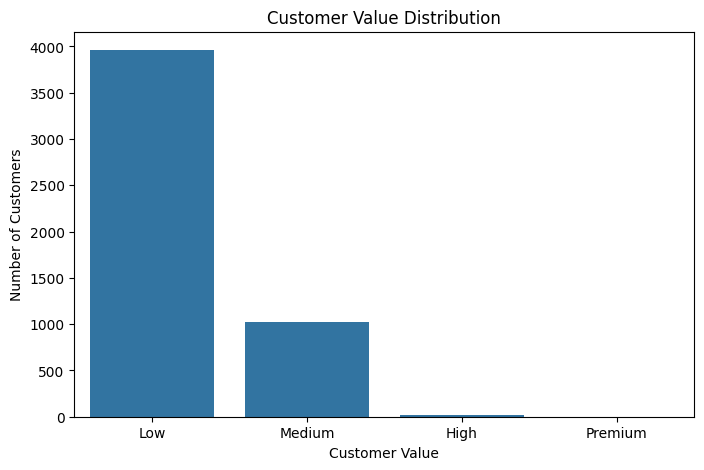

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Customer_Value")

plt.title("Customer Value Distribution")
plt.xlabel("Customer Value")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
df["Churn"].value_counts()


,count
Churn,
0,4793
1,207


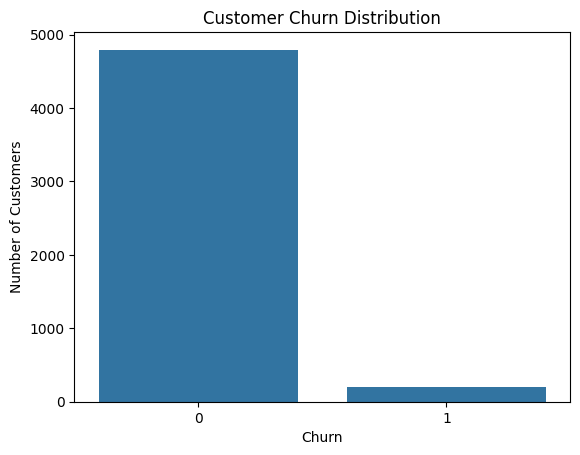

In [10]:
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
df["Customer_Value"].value_counts()


,count
Customer_Value,
Low,3961
Medium,1021
High,17
Premium,1


In [12]:
rfm = df[
    [
        "Customer_ID",
        "Recency_Days",
        "Frequency",
        "Monetary_Value"
    ]
].copy()

rfm.head()

,Customer_ID,Recency_Days,Frequency,Monetary_Value
0,CUST01502,104,8,387.81
1,CUST02587,120,5,139.28
2,CUST02654,47,15,228.35
3,CUST01056,81,8,643.28
4,CUST00706,73,5,258.46


In [13]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency_Days"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
)

In [14]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [15]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary_Value"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [16]:
rfm.head(10)



,Customer_ID,Recency_Days,Frequency,Monetary_Value,R_Score,F_Score,M_Score
0,CUST01502,104,8,387.81,2,2,3
1,CUST02587,120,5,139.28,1,1,1
2,CUST02654,47,15,228.35,5,4,2
3,CUST01056,81,8,643.28,3,2,5
4,CUST00706,73,5,258.46,3,1,3
5,CUST00107,110,3,159.69,1,1,2
6,CUST00590,142,4,104.61,1,1,1
7,CUST02469,83,5,221.48,3,1,2
8,CUST02414,81,8,399.14,3,2,4
9,CUST01601,33,18,635.58,5,5,4


In [17]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [18]:
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

In [19]:
rfm.head(10)

,Customer_ID,Recency_Days,Frequency,Monetary_Value,R_Score,F_Score,M_Score,RFM_Score
0,CUST01502,104,8,387.81,2,2,3,7
1,CUST02587,120,5,139.28,1,1,1,3
2,CUST02654,47,15,228.35,5,4,2,11
3,CUST01056,81,8,643.28,3,2,5,10
4,CUST00706,73,5,258.46,3,1,3,7
5,CUST00107,110,3,159.69,1,1,2,4
6,CUST00590,142,4,104.61,1,1,1,3
7,CUST02469,83,5,221.48,3,1,2,6
8,CUST02414,81,8,399.14,3,2,4,9
9,CUST01601,33,18,635.58,5,5,4,14


In [21]:
def rfm_category(score):
    if score >= 13:
        return "High Value"
    elif score >= 10:
        return "Potential Loyal"
    elif score >= 7:
        return "At Risk"
    else:
        return "Low Value"

In [22]:
rfm["RFM_Category"] = rfm["RFM_Score"].apply(rfm_category)

In [23]:
rfm["RFM_Category"].value_counts()

,count
RFM_Category,
Low Value,1471
At Risk,1250
Potential Loyal,1176
High Value,1103


In [24]:
df = df.merge(
    rfm[
        [
            "Customer_ID",
            "R_Score",
            "F_Score",
            "M_Score",
            "RFM_Score",
            "RFM_Category"
        ]
    ],
    on="Customer_ID",
    how="left"
)

In [25]:
df.head()

,Customer_ID,Age,Gender,Tenure_Months,Recency_Days,Frequency,Monetary_Value,Total_Purchases,Avg_Purchase_Value,Support_Calls,Website_Visits,Discount_Usage_Percent,Satisfaction_Score,Churn,Customer_Value,R_Score,F_Score,M_Score,RFM_Score,RFM_Category
0,CUST01502,30,Female,23,104,8,387.81,15,25.85,6,22,39,4.3,0,Low,2,2,3,7,At Risk
1,CUST02587,21,Female,25,120,5,139.28,10,13.93,5,20,48,5.5,1,Low,1,1,1,3,Low Value
2,CUST02654,47,Female,15,47,15,228.35,19,12.02,5,8,13,5.2,0,Low,5,4,2,11,Potential Loyal
3,CUST01056,29,Male,45,81,8,643.28,29,22.18,6,21,40,4.9,0,Low,3,2,5,10,Potential Loyal
4,CUST00706,43,Male,40,73,5,258.46,15,17.23,3,7,30,7.2,0,Low,3,1,3,7,At Risk


In [26]:
features = [
    "Age",
    "Tenure_Months",
    "Recency_Days",
    "Frequency",
    "Monetary_Value",
    "Total_Purchases",
    "Avg_Purchase_Value",
    "Support_Calls",
    "Website_Visits",
    "Discount_Usage_Percent",
    "Satisfaction_Score"
]

In [27]:
X = df[features].copy()

X.head()

,Age,Tenure_Months,Recency_Days,Frequency,Monetary_Value,Total_Purchases,Avg_Purchase_Value,Support_Calls,Website_Visits,Discount_Usage_Percent,Satisfaction_Score
0,30,23,104,8,387.81,15,25.85,6,22,39,4.3
1,21,25,120,5,139.28,10,13.93,5,20,48,5.5
2,47,15,47,15,228.35,19,12.02,5,8,13,5.2
3,29,45,81,8,643.28,29,22.18,6,21,40,4.9
4,43,40,73,5,258.46,15,17.23,3,7,30,7.2


In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(5000, 11)


In [29]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("PCA components:", X_pca.shape[1])

Original number of features: 11
PCA components: 2


In [30]:
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

PC1: 0.3948506253534499
PC2: 0.15426129197543445
Total: 0.5491119173288843


In [32]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

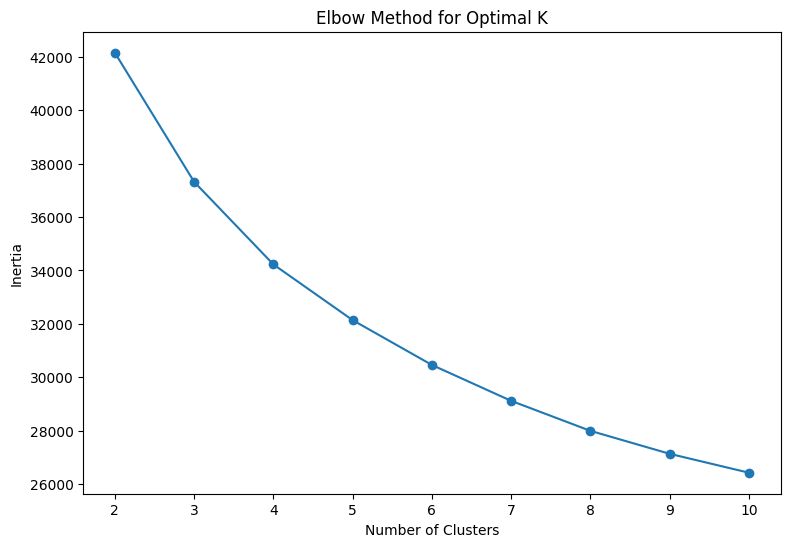

In [33]:
plt.figure(figsize=(9,6))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [34]:
K = 4

In [35]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

In [36]:
df["KMeans_Cluster"].value_counts().sort_index()

,count
KMeans_Cluster,
0,1888
1,430
2,929
3,1753


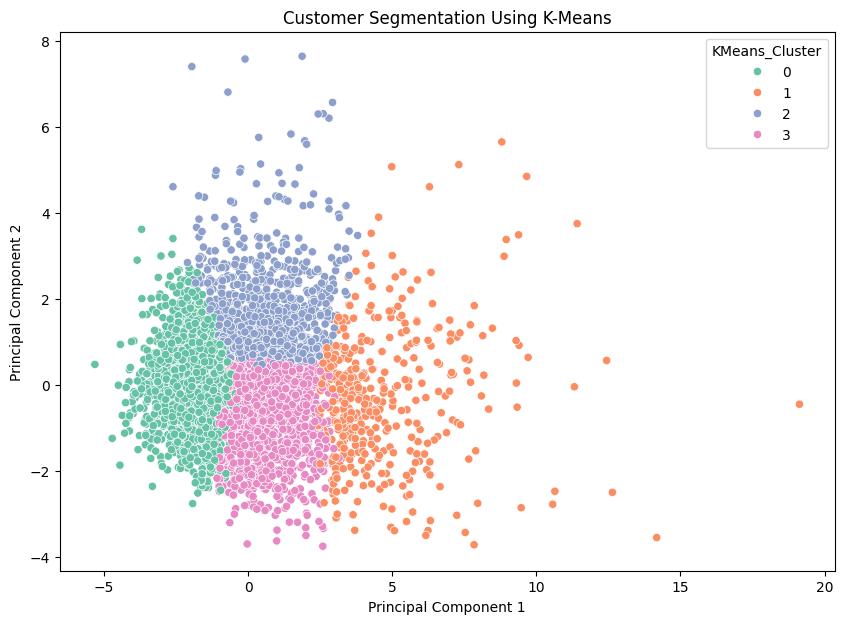

In [37]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["KMeans_Cluster"],
    palette="Set2"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation Using K-Means")

plt.show()

In [38]:
cluster_summary = df.groupby(
    "KMeans_Cluster"
)[features].mean()

cluster_summary

,Age,Tenure_Months,Recency_Days,Frequency,Monetary_Value,Total_Purchases,Avg_Purchase_Value,Support_Calls,Website_Visits,Discount_Usage_Percent,Satisfaction_Score
KMeans_Cluster,,,,,,,,,,,
0,36.363347,25.592161,107.070975,6.091631,208.847082,13.025953,19.586880,5.529661,17.048729,40.179555,5.861070
1,36.844186,56.860465,33.281395,25.158140,1177.777977,117.158140,12.061721,2.134884,78.404651,21.234884,9.002326
2,35.962325,19.023681,65.499462,13.397201,712.614478,21.739505,36.652831,3.315393,39.190527,28.133477,7.959526
3,36.270394,45.247576,65.978893,10.755277,381.072772,40.039361,10.562145,3.424986,32.960639,30.409584,7.604107


In [39]:
cluster_rfm = df.groupby(
    "KMeans_Cluster"
)[
    [
        "Recency_Days",
        "Frequency",
        "Monetary_Value",
        "RFM_Score",
        "Churn"
    ]
].mean()

cluster_rfm

,Recency_Days,Frequency,Monetary_Value,RFM_Score,Churn
KMeans_Cluster,,,,,
0,107.070975,6.091631,208.847082,5.601165,0.078390
1,33.281395,25.158140,1177.777977,14.360465,0.011628
2,65.499462,13.397201,712.614478,11.618945,0.021529
3,65.978893,10.755277,381.072772,9.957787,0.019395


In [41]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

df["GMM_Cluster"] = gmm.fit_predict(X_scaled)


In [42]:
df["GMM_Cluster"].value_counts().sort_index()

,count
GMM_Cluster,
0,1675
1,676
2,1048
3,1601


In [43]:
gmm_probabilities = gmm.predict_proba(X_scaled)

gmm_probabilities[:5]

array([[9.75031761e-01, 2.11491841e-08, 2.49682179e-02, 3.43914312e-24],
       [9.99922508e-01, 1.13575552e-08, 7.47766498e-05, 2.70351742e-06],
       [2.26037819e-06, 8.56228885e-04, 9.62441147e-01, 3.67003633e-02],
       [7.05512687e-05, 2.92595257e-02, 8.88591895e-01, 8.20780283e-02],
       [9.99700683e-01, 2.56571009e-04, 4.20848637e-05, 6.61598415e-07]])

In [44]:
df["GMM_Confidence"] = gmm_probabilities.max(axis=1)

df[
    [
        "Customer_ID",
        "GMM_Cluster",
        "GMM_Confidence"
    ]
].head(10)

,Customer_ID,GMM_Cluster,GMM_Confidence
0,CUST01502,0,0.975032
1,CUST02587,0,0.999923
2,CUST02654,2,0.962441
3,CUST01056,2,0.888592
4,CUST00706,0,0.999701
5,CUST00107,0,0.996387
6,CUST00590,0,0.999988
7,CUST02469,0,0.974882
8,CUST02414,0,0.957026
9,CUST01601,2,0.916015


In [45]:
gmm_summary = df.groupby(
    "GMM_Cluster"
)[
    [
        "Recency_Days",
        "Frequency",
        "Monetary_Value",
        "Support_Calls",
        "Satisfaction_Score",
        "Churn"
    ]
].mean()

gmm_summary

,Recency_Days,Frequency,Monetary_Value,Support_Calls,Satisfaction_Score,Churn
GMM_Cluster,,,,,,
0,99.389254,6.040000,201.517343,4.918209,6.317433,0.070448
1,43.505917,21.917160,1011.627855,2.639053,8.561538,0.010355
2,74.358779,11.920802,637.030716,3.800573,7.443702,0.030534
3,74.425984,10.114304,338.399169,4.020612,7.177264,0.031230


In [46]:
churn_by_cluster = df.groupby(
    "KMeans_Cluster"
)["Churn"].mean() * 100

churn_by_cluster

,Churn
KMeans_Cluster,
0,7.838983
1,1.162791
2,2.152853
3,1.939532


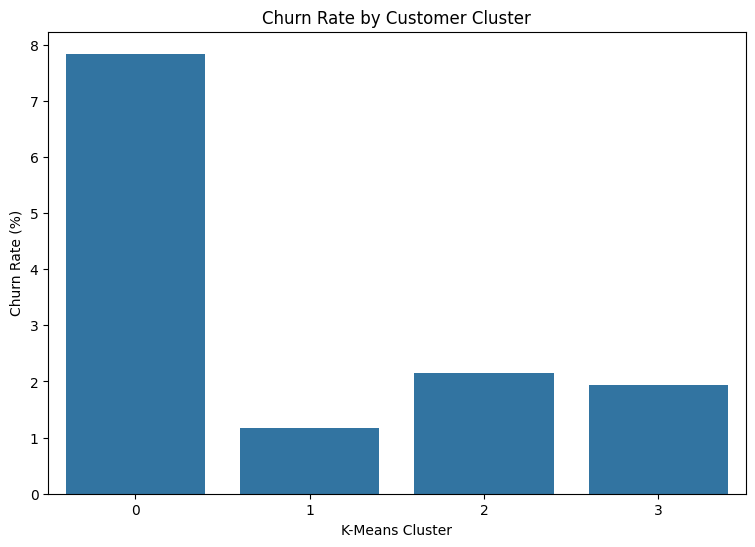

In [47]:
plt.figure(figsize=(9,6))

sns.barplot(
    x=churn_by_cluster.index,
    y=churn_by_cluster.values
)

plt.xlabel("K-Means Cluster")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Cluster")

plt.show()

In [48]:
cluster_rfm

,Recency_Days,Frequency,Monetary_Value,RFM_Score,Churn
KMeans_Cluster,,,,,
0,107.070975,6.091631,208.847082,5.601165,0.078390
1,33.281395,25.158140,1177.777977,14.360465,0.011628
2,65.499462,13.397201,712.614478,11.618945,0.021529
3,65.978893,10.755277,381.072772,9.957787,0.019395


In [49]:
segment_names = {
    0: "High Value Customers",
    1: "At Risk Customers",
    2: "Potential Loyal Customers",
    3: "Low Value Customers"
}

In [50]:
df["Customer_Segment"] = df["KMeans_Cluster"].map(
    segment_names
)

In [51]:
def get_recommendation(segment, churn):

    if segment == "High Value Customers" and churn == 0:
        return "Premium offers and VIP rewards"

    elif segment == "High Value Customers" and churn == 1:
        return "Immediate retention campaign"

    elif segment == "At Risk Customers":
        return "Discounts, reminders and win-back offers"

    elif segment == "Potential Loyal Customers":
        return "Personalized offers and loyalty rewards"

    elif segment == "Low Value Customers":
        return "Low-cost marketing"

    else:
        return "Monitor customer behavior"

In [52]:
df["Recommendation"] = df.apply(
    lambda row: get_recommendation(
        row["Customer_Segment"],
        row["Churn"]
    ),
    axis=1
)

In [53]:
final_result = df[
    [
        "Customer_ID",
        "Recency_Days",
        "Frequency",
        "Monetary_Value",
        "RFM_Score",
        "Customer_Segment",
        "Churn",
        "GMM_Confidence",
        "Recommendation"
    ]
]

final_result.head(20)

,Customer_ID,Recency_Days,Frequency,Monetary_Value,RFM_Score,Customer_Segment,Churn,GMM_Confidence,Recommendation
0,CUST01502,104,8,387.81,7,High Value Customers,0,0.975032,Premium offers and VIP rewards
1,CUST02587,120,5,139.28,3,High Value Customers,1,0.999923,Immediate retention campaign
2,CUST02654,47,15,228.35,11,Low Value Customers,0,0.962441,Low-cost marketing
3,CUST01056,81,8,643.28,10,High Value Customers,0,0.888592,Premium offers and VIP rewards
4,CUST00706,73,5,258.46,7,Low Value Customers,0,0.999701,Low-cost marketing
5,CUST00107,110,3,159.69,4,High Value Customers,0,0.996387,Premium offers and VIP rewards
6,CUST00590,142,4,104.61,3,High Value Customers,0,0.999988,Premium offers and VIP rewards
7,CUST02469,83,5,221.48,6,High Value Customers,0,0.974882,Premium offers and VIP rewards
8,CUST02414,81,8,399.14,9,High Value Customers,0,0.957026,Premium offers and VIP rewards
9,CUST01601,33,18,635.58,14,Potential Loyal Customers,0,0.916015,Personalized offers and loyalty rewards


In [54]:
high_value_risk = df[
    (df["Customer_Segment"] == "High Value Customers") &
    (df["Churn"] == 1)
]

high_value_risk[
    [
        "Customer_ID",
        "Monetary_Value",
        "Frequency",
        "RFM_Score",
        "Churn",
        "Recommendation"
    ]
].head(20)

,Customer_ID,Monetary_Value,Frequency,RFM_Score,Churn,Recommendation
1,CUST02587,139.28,5,3,1,Immediate retention campaign
30,CUST01963,57.80,3,3,1,Immediate retention campaign
45,CUST03907,115.15,5,3,1,Immediate retention campaign
61,CUST04396,96.77,4,4,1,Immediate retention campaign
66,CUST03341,125.15,3,3,1,Immediate retention campaign
81,CUST03182,105.82,4,3,1,Immediate retention campaign
84,CUST03025,255.77,8,5,1,Immediate retention campaign
110,CUST01407,94.91,7,4,1,Immediate retention campaign
117,CUST02095,59.46,2,3,1,Immediate retention campaign
127,CUST04772,129.08,7,4,1,Immediate retention campaign


In [55]:
premium_customers = df[
    (df["Customer_Segment"] == "High Value Customers") &
    (df["Churn"] == 0)
]

premium_customers.head(20)

,Customer_ID,Age,Gender,Tenure_Months,Recency_Days,Frequency,Monetary_Value,Total_Purchases,Avg_Purchase_Value,Support_Calls,...,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,KMeans_Cluster,GMM_Cluster,GMM_Confidence,Customer_Segment,Recommendation
0,CUST01502,30,Female,23,104,8,387.81,15,25.85,6,...,2,2,3,7,At Risk,0,0,0.975032,High Value Customers,Premium offers and VIP rewards
3,CUST01056,29,Male,45,81,8,643.28,29,22.18,6,...,3,2,5,10,Potential Loyal,0,2,0.888592,High Value Customers,Premium offers and VIP rewards
5,CUST00107,57,Female,23,110,3,159.69,6,26.62,6,...,1,1,2,4,Low Value,0,0,0.996387,High Value Customers,Premium offers and VIP rewards
6,CUST00590,27,Male,25,142,4,104.61,8,13.08,5,...,1,1,1,3,Low Value,0,0,0.999988,High Value Customers,Premium offers and VIP rewards
7,CUST02469,44,Female,12,83,5,221.48,6,36.91,7,...,3,1,2,6,Low Value,0,0,0.974882,High Value Customers,Premium offers and VIP rewards
8,CUST02414,26,Male,20,81,8,399.14,12,33.26,5,...,3,2,4,9,At Risk,0,0,0.957026,High Value Customers,Premium offers and VIP rewards
12,CUST00916,39,Female,25,107,5,306.39,9,34.04,5,...,2,1,3,6,Low Value,0,0,0.992406,High Value Customers,Premium offers and VIP rewards
15,CUST03544,24,Female,30,83,6,131.14,16,8.20,5,...,3,2,1,6,Low Value,0,0,0.829571,High Value Customers,Premium offers and VIP rewards
16,CUST01074,22,Female,28,119,4,134.68,9,14.96,1,...,1,1,1,3,Low Value,0,0,0.999953,High Value Customers,Premium offers and VIP rewards
24,CUST04768,33,Male,10,140,5,199.98,5,40.00,3,...,1,1,2,4,Low Value,0,0,0.575470,High Value Customers,Premium offers and VIP rewards


In [56]:
low_value_customers = df[
    df["Customer_Segment"] == "Low Value Customers"
]

low_value_customers.head(20)

,Customer_ID,Age,Gender,Tenure_Months,Recency_Days,Frequency,Monetary_Value,Total_Purchases,Avg_Purchase_Value,Support_Calls,...,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,KMeans_Cluster,GMM_Cluster,GMM_Confidence,Customer_Segment,Recommendation
2,CUST02654,47,Female,15,47,15,228.35,19,12.02,5,...,5,4,2,11,Potential Loyal,3,2,0.962441,Low Value Customers,Low-cost marketing
4,CUST00706,43,Male,40,73,5,258.46,15,17.23,3,...,3,1,3,7,At Risk,3,0,0.999701,Low Value Customers,Low-cost marketing
11,CUST00229,28,Male,65,67,8,551.03,42,13.12,2,...,4,2,4,10,Potential Loyal,3,3,0.996866,Low Value Customers,Low-cost marketing
13,CUST00795,24,Male,28,83,14,536.24,32,16.76,4,...,3,4,4,11,Potential Loyal,3,3,0.853499,Low Value Customers,Low-cost marketing
21,CUST03050,49,Female,45,60,7,263.78,30,8.79,6,...,4,2,3,9,At Risk,3,3,0.999667,Low Value Customers,Low-cost marketing
22,CUST01118,35,Female,41,48,13,547.38,41,13.35,6,...,5,4,4,13,High Value,3,3,0.999881,Low Value Customers,Low-cost marketing
23,CUST00643,33,Female,39,93,10,355.68,33,10.78,5,...,2,3,3,8,At Risk,3,3,0.999577,Low Value Customers,Low-cost marketing
31,CUST00394,56,Female,62,91,8,380.84,44,8.66,3,...,2,2,3,7,At Risk,3,3,0.999643,Low Value Customers,Low-cost marketing
36,CUST03586,22,Female,62,41,19,395.95,90,4.40,2,...,5,5,4,14,High Value,3,1,0.999188,Low Value Customers,Low-cost marketing
38,CUST04967,26,Female,89,60,10,145.44,63,2.31,2,...,4,3,1,8,At Risk,3,1,0.830462,Low Value Customers,Low-cost marketing


In [57]:
low_value_customers = df[
    df["Customer_Segment"] == "Low Value Customers"
]

low_value_customers.head(20)

,Customer_ID,Age,Gender,Tenure_Months,Recency_Days,Frequency,Monetary_Value,Total_Purchases,Avg_Purchase_Value,Support_Calls,...,R_Score,F_Score,M_Score,RFM_Score,RFM_Category,KMeans_Cluster,GMM_Cluster,GMM_Confidence,Customer_Segment,Recommendation
2,CUST02654,47,Female,15,47,15,228.35,19,12.02,5,...,5,4,2,11,Potential Loyal,3,2,0.962441,Low Value Customers,Low-cost marketing
4,CUST00706,43,Male,40,73,5,258.46,15,17.23,3,...,3,1,3,7,At Risk,3,0,0.999701,Low Value Customers,Low-cost marketing
11,CUST00229,28,Male,65,67,8,551.03,42,13.12,2,...,4,2,4,10,Potential Loyal,3,3,0.996866,Low Value Customers,Low-cost marketing
13,CUST00795,24,Male,28,83,14,536.24,32,16.76,4,...,3,4,4,11,Potential Loyal,3,3,0.853499,Low Value Customers,Low-cost marketing
21,CUST03050,49,Female,45,60,7,263.78,30,8.79,6,...,4,2,3,9,At Risk,3,3,0.999667,Low Value Customers,Low-cost marketing
22,CUST01118,35,Female,41,48,13,547.38,41,13.35,6,...,5,4,4,13,High Value,3,3,0.999881,Low Value Customers,Low-cost marketing
23,CUST00643,33,Female,39,93,10,355.68,33,10.78,5,...,2,3,3,8,At Risk,3,3,0.999577,Low Value Customers,Low-cost marketing
31,CUST00394,56,Female,62,91,8,380.84,44,8.66,3,...,2,2,3,7,At Risk,3,3,0.999643,Low Value Customers,Low-cost marketing
36,CUST03586,22,Female,62,41,19,395.95,90,4.40,2,...,5,5,4,14,High Value,3,1,0.999188,Low Value Customers,Low-cost marketing
38,CUST04967,26,Female,89,60,10,145.44,63,2.31,2,...,4,3,1,8,At Risk,3,1,0.830462,Low Value Customers,Low-cost marketing


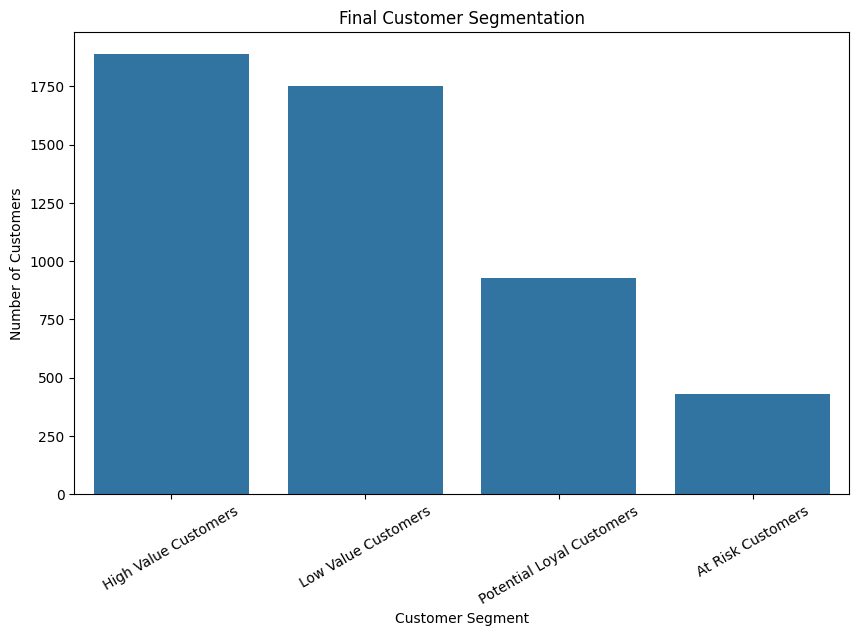

In [58]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Customer_Segment",
    order=df["Customer_Segment"].value_counts().index
)

plt.xticks(rotation=30)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Final Customer Segmentation")

plt.show()